In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [113]:
df = pd.read_csv('data/train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [114]:
df.shape

(1460, 81)

**Uniforming the column names**

In [115]:
df = df.rename(columns={i:i.lower() for i in df.columns})

**Feature Engineering**

In [116]:
df['age'] = df['yrsold'] - df['yearbuilt']  #making a new column called age which denotes the age of the house, subtracting yearsold and yearbuilt
df['remode_age'] = df['yrsold'] - df['yearremodadd'] #counting the number of years since the year when the house was renovated till the year it was sold.
df = df.drop(columns = ['yrsold','yearbuilt','yearremodadd','id'])

In [117]:
df.columns

Index(['mssubclass', 'mszoning', 'lotfrontage', 'lotarea', 'street', 'alley',
       'lotshape', 'landcontour', 'utilities', 'lotconfig', 'landslope',
       'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle',
       'overallqual', 'overallcond', 'roofstyle', 'roofmatl', 'exterior1st',
       'exterior2nd', 'masvnrtype', 'masvnrarea', 'exterqual', 'extercond',
       'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure', 'bsmtfintype1',
       'bsmtfinsf1', 'bsmtfintype2', 'bsmtfinsf2', 'bsmtunfsf', 'totalbsmtsf',
       'heating', 'heatingqc', 'centralair', 'electrical', '1stflrsf',
       '2ndflrsf', 'lowqualfinsf', 'grlivarea', 'bsmtfullbath', 'bsmthalfbath',
       'fullbath', 'halfbath', 'bedroomabvgr', 'kitchenabvgr', 'kitchenqual',
       'totrmsabvgrd', 'functional', 'fireplaces', 'fireplacequ', 'garagetype',
       'garageyrblt', 'garagefinish', 'garagecars', 'garagearea', 'garagequal',
       'garagecond', 'paveddrive', 'wooddecksf', 'openporchsf',
       'en

**Checking the null values**

In [118]:
num_null_features = df.isnull().any().sum()
print(f'The total number of features having null values are: {num_null_features}')

The total number of features having null values are: 19


**Checking the features having null values**

In [119]:
null_features = df.isnull().sum()[df.isnull().sum()>0]
print(f'The features having the null values are: \n{null_features}')

The features having the null values are: 
lotfrontage      259
alley           1369
masvnrtype       872
masvnrarea         8
bsmtqual          37
bsmtcond          37
bsmtexposure      38
bsmtfintype1      37
bsmtfintype2      38
electrical         1
fireplacequ      690
garagetype        81
garageyrblt       81
garagefinish      81
garagequal        81
garagecond        81
poolqc          1453
fence           1179
miscfeature     1406
dtype: int64


**Checking the features having duplicate values**

In [120]:
df.duplicated().sum()

np.int64(0)

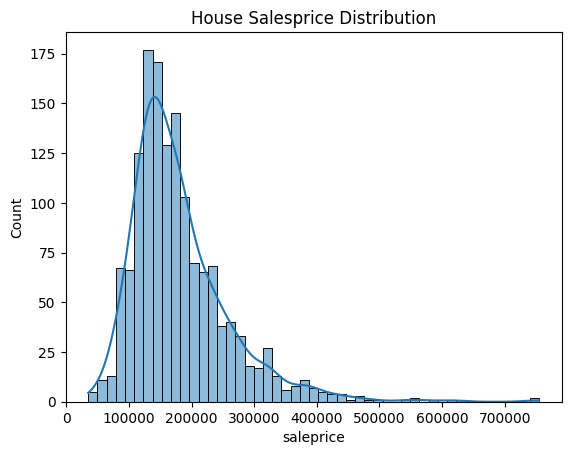

In [121]:
sns.histplot(df['saleprice'],kde=True)
plt.title('House Salesprice Distribution')
plt.show()


**We can observe from the plot above that the majority of house salesprice lie between the range of 150000 and 250000**

In [122]:
df['mssubclass'] = df['mssubclass'].astype(str)

In [123]:
df['mszoning'].value_counts()

mszoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

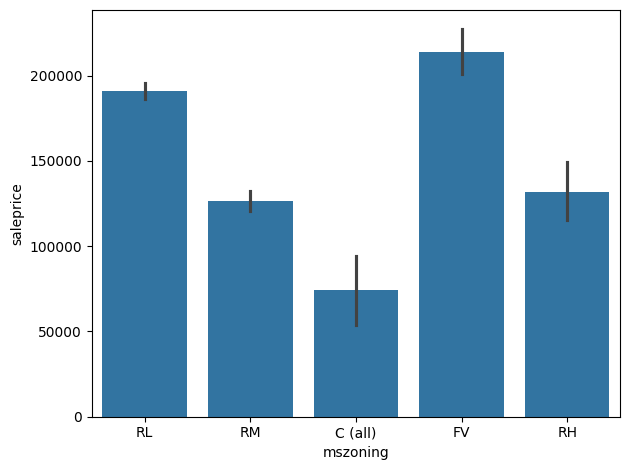

In [124]:
sns.barplot(x='mszoning',y='saleprice',data=df)
plt.tight_layout()
plt.show()

**“The bar plot indicates that zoning classification has a significant impact on sale price. Properties in premium residential zones such as FV exhibit the highest average prices, followed by RL (suburban residential areas). Meanwhile, properties in commercial zones (C) show comparatively lower average prices, possibly due to differences in property type and limited representation in the dataset.”**

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mssubclass     1460 non-null   str    
 1   mszoning       1460 non-null   str    
 2   lotfrontage    1201 non-null   float64
 3   lotarea        1460 non-null   int64  
 4   street         1460 non-null   str    
 5   alley          91 non-null     str    
 6   lotshape       1460 non-null   str    
 7   landcontour    1460 non-null   str    
 8   utilities      1460 non-null   str    
 9   lotconfig      1460 non-null   str    
 10  landslope      1460 non-null   str    
 11  neighborhood   1460 non-null   str    
 12  condition1     1460 non-null   str    
 13  condition2     1460 non-null   str    
 14  bldgtype       1460 non-null   str    
 15  housestyle     1460 non-null   str    
 16  overallqual    1460 non-null   int64  
 17  overallcond    1460 non-null   int64  
 18  roofstyle      1460

In [126]:
numerical_features = df.select_dtypes(include = np.number).columns.tolist()  #grabbing all the features of type number 'int or float'
categorical_features = df.select_dtypes(exclude = np.number).columns.tolist()  #grabbing the features which are not of type number
print(f'The categorical features are: {categorical_features} \n')
print(f'The numerical features are: {numerical_features}')
print(f'The number of numerical features is: {len(numerical_features)}')
print(f'The number of categorical features is: {len(categorical_features)}')

The categorical features are: ['mssubclass', 'mszoning', 'street', 'alley', 'lotshape', 'landcontour', 'utilities', 'lotconfig', 'landslope', 'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle', 'roofstyle', 'roofmatl', 'exterior1st', 'exterior2nd', 'masvnrtype', 'exterqual', 'extercond', 'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure', 'bsmtfintype1', 'bsmtfintype2', 'heating', 'heatingqc', 'centralair', 'electrical', 'kitchenqual', 'functional', 'fireplacequ', 'garagetype', 'garagefinish', 'garagequal', 'garagecond', 'paveddrive', 'poolqc', 'fence', 'miscfeature', 'saletype', 'salecondition'] 

The numerical features are: ['lotfrontage', 'lotarea', 'overallqual', 'overallcond', 'masvnrarea', 'bsmtfinsf1', 'bsmtfinsf2', 'bsmtunfsf', 'totalbsmtsf', '1stflrsf', '2ndflrsf', 'lowqualfinsf', 'grlivarea', 'bsmtfullbath', 'bsmthalfbath', 'fullbath', 'halfbath', 'bedroomabvgr', 'kitchenabvgr', 'totrmsabvgrd', 'fireplaces', 'garageyrblt', 'garagecars', 'garagearea', 'wood

In [127]:
one_hot_encode_nominal_cat= ['mssubclass','mszoning','alley','landcontour','lotconfig','neighborhood','condition1','condition2','bldgtype','housestyle','roofstyle','roofmatl','exterior1st','exterior1st','masvnrtype','foundation','heating','garagetype','miscfeature','saletype','salecondition']
binary_encode_nominal_cat = ['street','centralair','']
ordinal_cat = ['lotshape','utilities','landslope','exterqual','extercond','bsmtqual','bsmtcond','bsmtexposure','bsmtfintype1','bsmtfintype2','heatingqc','kitchenqual','fireplacequ','functional','garagefinish','garagequal','garagecond','paveddrive','poolqc','fence']
print(f'The number of nominal categories that need one hot encoding is: {len(one_hot_encode_nominal_cat)}')
print(f'The number of nominal categories that need binary encoding is: {len(binary_encode_nominal_cat)}')
print(f'The number of ordinal categories is: {len(ordinal_cat)}')

The number of nominal categories that need one hot encoding is: 21
The number of nominal categories that need binary encoding is: 3
The number of ordinal categories is: 20


**Studying relationship of the numerical features with the target variable**

In [145]:
corelation = df[numerical_features].corr()['saleprice'].sort_values(ascending = False)
imp_num_features = corelation[abs(corelation) > 0.1]
imp_num_features


saleprice        1.000000
overallqual      0.790982
grlivarea        0.708624
garagecars       0.640409
garagearea       0.623431
totalbsmtsf      0.613581
1stflrsf         0.605852
fullbath         0.560664
totrmsabvgrd     0.533723
garageyrblt      0.486362
masvnrarea       0.477493
fireplaces       0.466929
bsmtfinsf1       0.386420
lotfrontage      0.351799
wooddecksf       0.324413
2ndflrsf         0.319334
openporchsf      0.315856
halfbath         0.284108
lotarea          0.263843
bsmtfullbath     0.227122
bsmtunfsf        0.214479
bedroomabvgr     0.168213
screenporch      0.111447
enclosedporch   -0.128578
kitchenabvgr    -0.135907
remode_age      -0.509079
age             -0.523350
Name: saleprice, dtype: float64

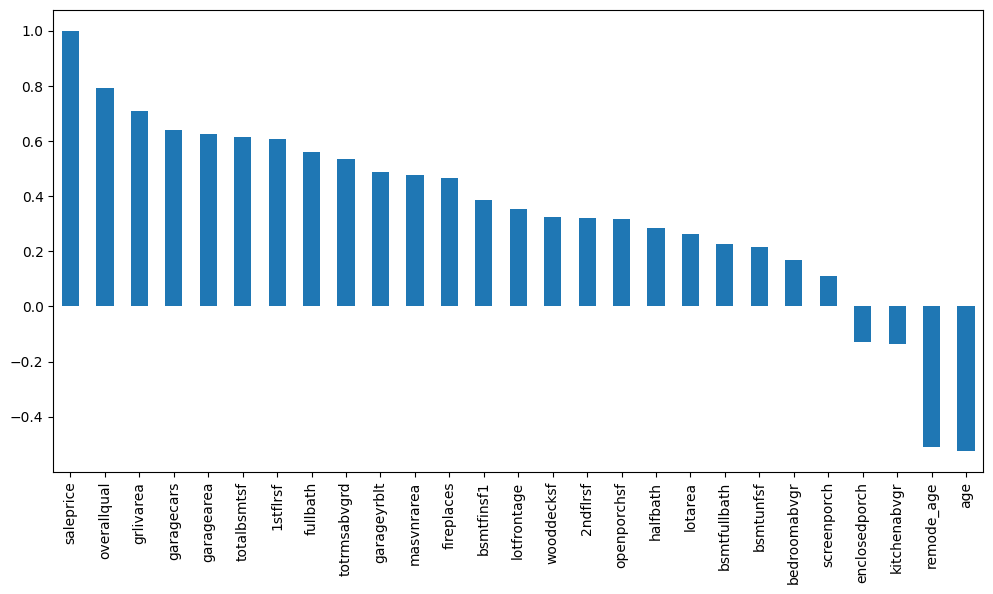

In [146]:
plt.figure(figsize = (12,6))
imp_num_features.plot(kind='bar')
plt.show()
